# package


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors


from importlib import reload
package_Lab=reload(package_Lab)

import package_Lab
from package_Lab import LL_RT, PID_RT,IMC_tuning, Margin, Controller
import package_Lab
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode


from importlib import reload
package_Lab=reload(package_Lab)

# LL_RT()

In [27]:
help(LL_RT)

Help on function LL_RT in module package_Lab:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "LL_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "LL_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

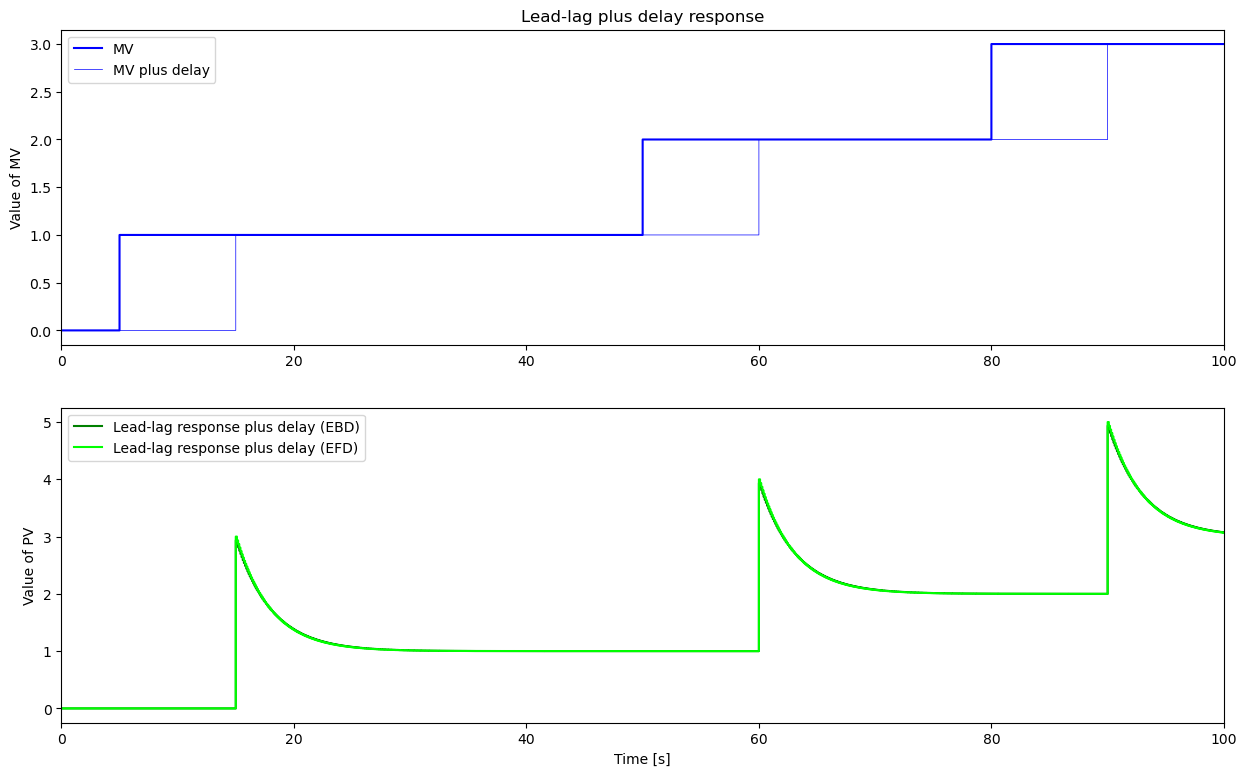

In [28]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV en gros ça va être un step de 0 à 1 à t=5s, puis un step de 1 à 2 à t=50s, puis un step de 2 à 3 à t=80s, et enfin un step de 3 à 3 à t=100s (pas de changement)
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
MVDelay = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []

# Parameters
Kp = 1
Tlag = 3
Tlead = 9
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    Delay_RT(MV,theta,Ts,MVDelay)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EBD)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    #LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV')
plt.title('Lead-lag plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='Lead-lag response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'lime',label='Lead-lag response plus delay (EFD)',where='post')
#plt.step(t,PV_TRAP,'springgreen',label='Lead-lag response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# PID


[0.0] initial MVI


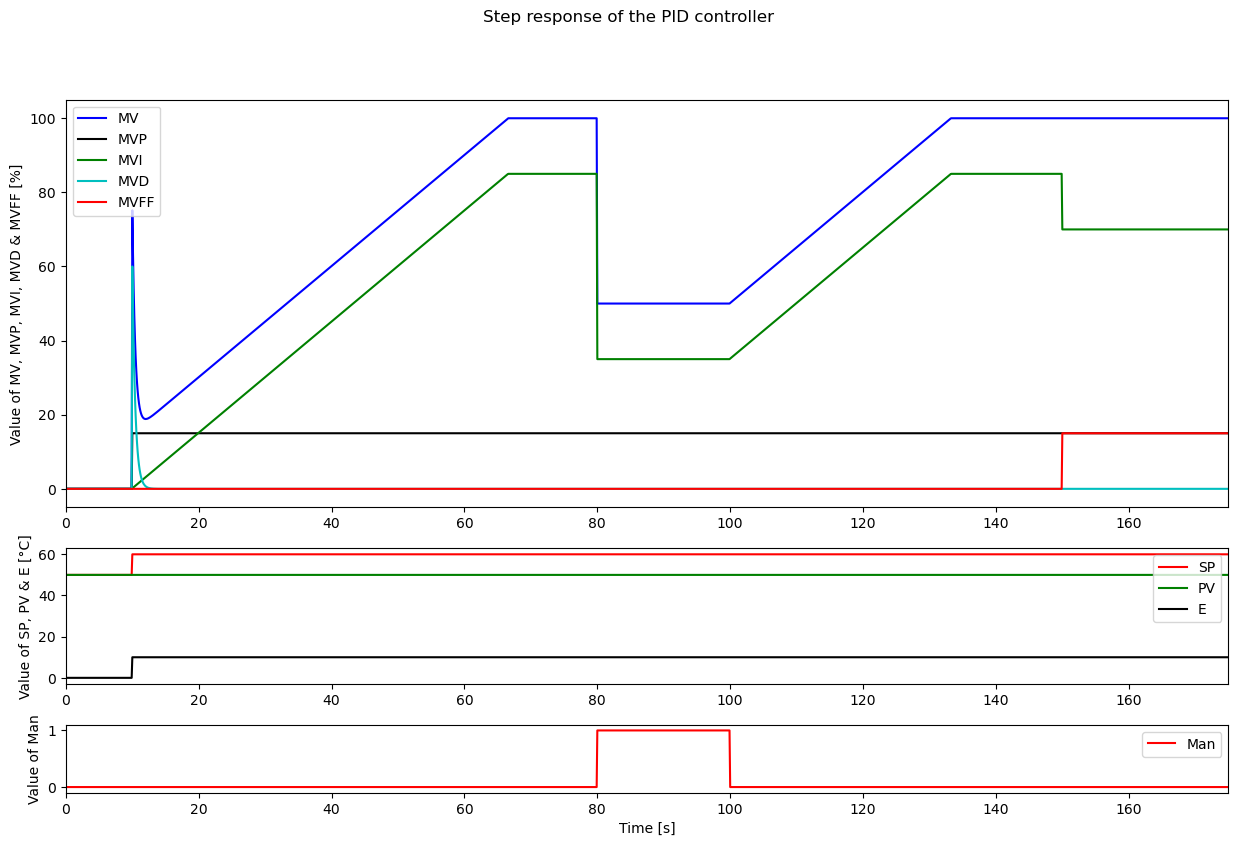

In [29]:
TSim = 175
Ts = 0.1
N = int(TSim/Ts) + 1

#para
Kc = 1.5 
Ti = 10 
Td = 2
alpha = 0.2 
MVMAx = 100 
MVMin = 0



MVPath = {0: 0, 5: 1, 50: 2, 100: 3,150: 3, TSim: 3} 
SPPath = {0: 50, 10: 60, 50: 60, 100: 60,150: 60, TSim: 60} 
PVPath = {0: 50, 5: 50, 50: 50, 100: 50,150: 50, TSim: 50} 
MANPath = {0: False, 5: False, 80: True, 100: False,150: False, TSim: False} 
MVFFPath = {0: 0, 5: 0, 50: 0, 100: 0, 150: 15, TSim: 15} 
MVMANPath = {0: 0, 5: 0, 50: 50, 100: 50,150: 50, TSim: 50}

t= [] 
PV = [] 
SP = [] 
MAN = [] 
MVMan = [] 
MV = [] 
MVFF = [] 
MVP = [] 
MVI = [] 
MVD = [] 
E = []
for i in range(0,N):
    t.append(i*Ts) 
    SelectPath_RT(SPPath,t,SP) 
    SelectPath_RT(PVPath,t,PV) 
    SelectPath_RT(MANPath,t,MAN) 
    SelectPath_RT(MVMANPath,t,MVMan) 
    SelectPath_RT(MVFFPath,t,MVFF) 
    PID_RT(SP, PV,MAN,MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMAx, MV, MVP, MVI, MVD, E, PVInit=50)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 9), gridspec_kw={'height_ratios': [3, 1, 0.5]})
fig.suptitle('Step response of the PID controller')

# Top: all MV signals
ax1.plot(t, MV,   'b-', label='MV')
ax1.plot(t, MVP,  'k-', label='MVP')
ax1.plot(t, MVI,  'g-', label='MVI')
ax1.plot(t, MVD,  'c-', label='MVD')
ax1.plot(t, MVFF, 'r-', label='MVFF')
ax1.set_ylabel('Value of MV, MVP, MVI, MVD & MVFF [%]')
ax1.legend(loc='upper left')
ax1.set_xlim([0, TSim])

# Middle: SP, PV, Error
ax2.plot(t, SP, 'r-', label='SP')
ax2.plot(t, PV, 'g-', label='PV')
ax2.plot(t, E,  'k-', label='E')
ax2.set_ylabel('Value of SP, PV & E [°C]')
ax2.legend(loc='upper right')
ax2.set_xlim([0, TSim])

# Bottom: Manual mode
MAN_int = [1 if m else 0 for m in MAN]
ax3.plot(t, MAN_int, 'r-', label='Man')
ax3.set_ylabel('Value of Man')
ax3.set_xlabel('Time [s]')
ax3.set_ylim([-0.1, 1.1])
ax3.legend(loc='upper right')
ax3.set_xlim([0, TSim])


plt.show()



# Simulation CLP PID FF

In [ ]:
from package_Lab import IMC_tuning


TSim = 3000
Ts = 0.5
N = int(TSim/Ts) + 1

MV0 = 50
DV0 = 50
PV0 = 54 #point de fonctionnement, trouver en faisant 50 50 sur le systeme

#Paramètres 




#Second ordre
Kp = 0.3768941279826313
T1p = TLead1 = 187.1409297022807
T2p = TLead2 = 10.452990644869
theta_p =  13.137983829128451 


P_SOPDT = Process({}) # Default process = unit gain

# Parameters for input-output dynamics P(s)
P_SOPDT.parameters['Kp'] = Kp
P_SOPDT.parameters['Tlag1'] = T1p
P_SOPDT.parameters['Tlag2'] = T2p
P_SOPDT.parameters['theta'] = theta_p

#Premier ordre
Kp_FOPDTOPT =  0.37720311160467174
T_FOPDTOPT =  188.30559411020332
theta_FOPDTOPT = 23.189177284051183

#Perturbation
Kd = 0.3241048096246215
T1d = Tlag1 = 221.16602071422838 
T2d = Tlag2 = 16.741635805529068
theta_d = 5.453465939559135


#C
gamma = 0.9

Ti_IMC,Td_IMC,Kc_IMC = IMC_tuning(Kp, T1p,T2p,theta_p,gamma)
alpha_IMC = 0.9
print('Kc = ',Kc_IMC)
print('Ti = ',Ti_IMC)
print('Td = ',Td_IMC)


# C = Controller({})

# C.parameters["Kc"] = Kc_IMC
# C.parameters["Ti"] = Ti_IMC
# C.parameters["Td"] = Td_IMC
# C.parameters["TFD"] = alpha_IMC*Td_IMC
# C.parameters["E"] = 10
omega = np.logspace(-4, 1, 10000)


C = Kc_IMC*(1 + 1/(Ti_IMC*1j*omega) + (Td_IMC*1j*omega)/(alpha_IMC*Td_IMC*1j*omega + 1))



P_Bode = Bode(P_SOPDT,omega, Show=False)

Margin(P_Bode, C, omega)

Kc =  2.887503384440852
Ti =  197.5939203471497
Td =  9.90001303690539


TypeError: unsupported operand type(s) for *: 'complex' and 'Controller'

# Scénarios

In [31]:
# #Scénario OLP sans FF
# SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: False, TSim: False} 
# MVMANPath = {0: MV0+10, TSim: MV0+10}
# StateFF = False
# ManFF =  False

# #Scénario OLP + FF
# SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: False, TSim: False} 
# MVMANPath = {0: MV0+10, TSim: MV0+10}
# StateFF = True
# ManFF =  True

# #Scénario CLP sans FF
# SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: False, TSim: False} 
# MVMANPath = {0: MV0+10, TSim: MV0+10}
# StateFF = False
# ManFF =  False

#Scénario CLP + FF
SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
MANPath = {0: True, 400: False, TSim: False} 
MVMANPath = {0: MV0+10, TSim: MV0+10}
StateFF = True
ManFF =  False


In [32]:
MVMAx = 100 
MVMin = 0

t = []
PV= []
SP = []
MV = []
DV = []
MV_PID = []
MVI = []
MVP = []
MVD = []

MAN = []
MVMAN = []


E = []
PV1 = []


#FF
MANFF = []
MVFF = []
MVFFDelay = []

#P(s) Parameters

MVDelayp = []
PV1p = []
PV2p = []

#D(s) Parameters
MVDelayd = []
PV1d = []
PV2d = []

for i in range(0,N):
    t.append(i*Ts)
    
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    SelectPath_RT(MANPath,t,MAN) 
    SelectPath_RT(MVMANPath,t,MVMAN) 
    
    #FF
    
    Delay_RT(DV - DV0*np.ones_like(DV), np.max([theta_d-theta_p,0]),Ts,MVFFDelay)
    LL_RT(MVFFDelay,-Kd/Kp,Tlag1,TLead1,Ts,PV1)

    if StateFF:
        LL_RT(PV1,1,Tlag2,TLead2,Ts,MVFF)
    else:
        LL_RT(PV1,0,Tlag2,TLead2,Ts,MVFF)       

    

    PID_RT(SP, PV,MAN,MVMAN, MVFF, Kc_IMC, Ti_IMC, Td_IMC, alpha_IMC, Ts, MVMin, MVMAx, MV, MVP, MVI, MVD, E, ManFF, PV0)

   

    #Input-output dynamics P(s)
    Delay_RT(MV,theta_p,Ts,MVDelayp,MV0)
    FO_RT(MVDelayp,Kp,T1p,Ts,PV1p,0) 
    FO_RT(PV1p,1,T2p,Ts,PV2p,0)

    #Disturbance dynamics D(s)
    Delay_RT(DV - DV0*np.ones_like(DV), theta_d,Ts,MVDelayd,0)
    FO_RT(MVDelayd,Kd,T1d,Ts,PV1d,0)
    FO_RT(PV1d,1,T2d,Ts,PV2d,0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

[0.03653330248430522] initial MVI


# Plot

In [33]:
print(f"t:    {len(t)}")
print(f"MV:   {len(MV)}")
print(f"MVP:  {len(MVP)}")
print(f"MVI:  {len(MVI)}")
print(f"MVD:  {len(MVD)}")
print(f"MVFF: {len(MVFF)}")
print(f"SP:   {len(SP)}")
print(f"PV:   {len(PV)}")
print(f"DV:   {len(DV)}")

t:    6001
MV:   6001
MVP:  6001
MVI:  6001
MVD:  6001
MVFF: 6001
SP:   6001
PV:   6001
DV:   6001


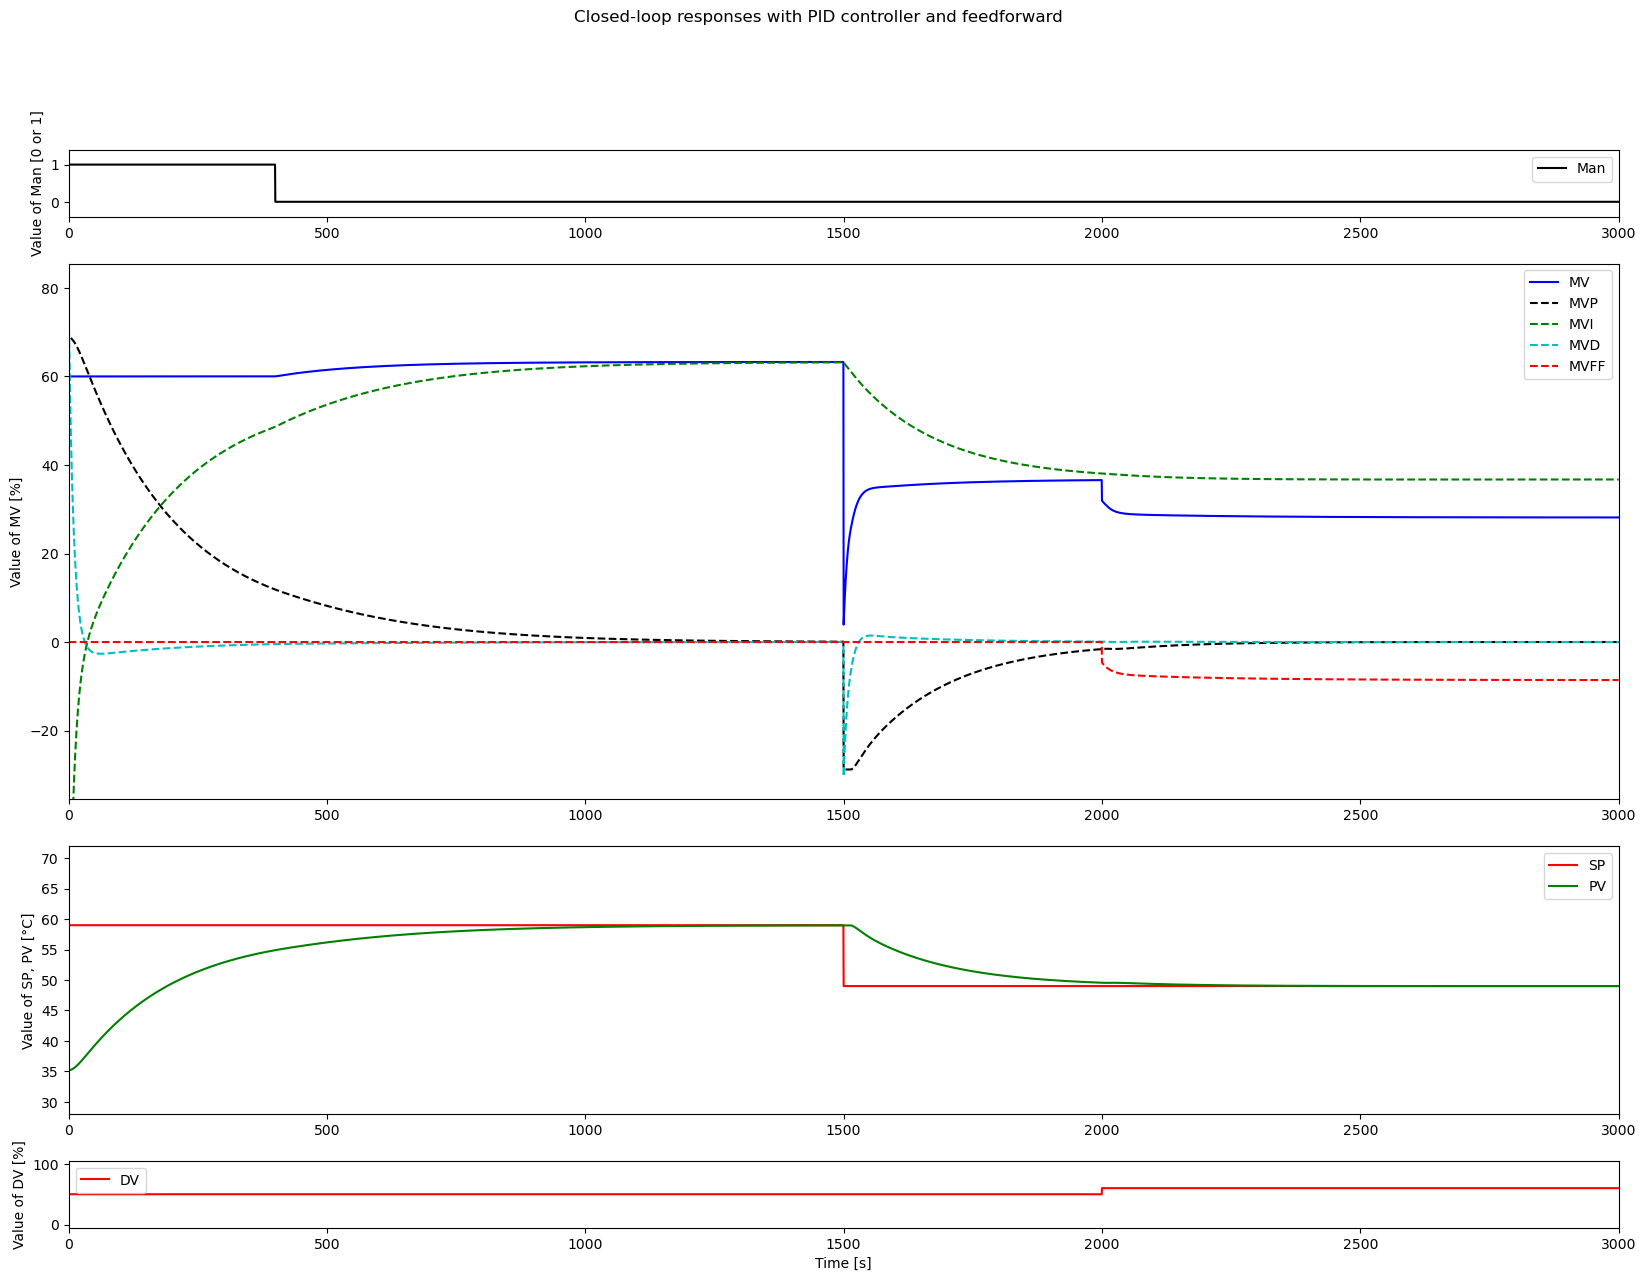

In [34]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(4, 1,figsize=(20, 14), gridspec_kw={'height_ratios': [1, 8, 4,1]})
fig.suptitle('Closed-loop responses with PID controller and feedforward')

#Manual Mode
MAN_int = [1 if m else 0 for m in MAN]
l1, = ax1.plot(t, MAN_int, 'k-', label='Man')
ax1.set_ylabel('Value of Man [0 or 1]')
ax1.set_ylim([-0.4, 1.4])
ax1.legend(loc='upper right')
ax1.set_xlim([0, TSim])

#MV
l2, = ax2.plot([0,TSim], [-30,80],   'b-', label='MV')
l3, = ax2.plot([0,TSim], [-30,80],  'k--', label='MVP')
l4, = ax2.plot([0,TSim], [-30,80],  'g--', label='MVI')
l5, = ax2.plot([0,TSim], [-30,80],  'c--', label='MVD')
l6, = ax2.plot([0,TSim], [-30,80], 'r--', label='MVFF')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='upper right')
ax2.set_xlim([0, TSim])

# SP, PV

l7, = ax3.plot([0,TSim], [30,70], 'r-', label='SP')
l8, = ax3.plot([0,TSim], [30,70], 'g-', label='PV')
ax3.set_ylabel('Value of SP, PV [°C]')
ax3.legend(loc='upper right')
ax3.set_xlim([0, TSim])

# DV


l9, = ax4.plot([0,TSim], [0,100], 'r-', label='DV')
ax4.set_ylabel('Value of DV [%]')

ax4.set_xlabel('Time [s]')
ax4.legend(loc='upper left')
ax4.set_xlim([0, TSim])


l1.set_data(t,MAN)

l2.set_data(t,MV)
l3.set_data(t,MVP)
l4.set_data(t,MVI)
l5.set_data(t,MVD)
l6.set_data(t,MVFF)

l7.set_data(t,SP)
l8.set_data(t,PV)

l9.set_data(t,DV)


plt.show()

In [35]:

omega = np.logspace(-4, 1, 10000)

C = K


Margin(P, C, omega)


NameError: name 'K' is not defined